In [1]:
import numpy as np, nibabel as nb
from pathlib import Path
import Functional_Fusion.dataset as ds
import Functional_Fusion.atlas_map as am

In [2]:
base_dir = '/Volumes/diedrichsen_data$/data/FunctionalFusion_new'
atlas_name = 'MNISymOlive1'
rest = 'rest'                                  # the task_code of your rest regressor
out_dir = Path('/Users/incehusain/olive_contrasts')
out_dir.mkdir(exist_ok=True)

dataset = ds.DataSetNative(base_dir + '/Olive')
atlas, _ = am.get_atlas(atlas_name)

for s in dataset.get_participants().participant_id:
    d, inf = dataset.get_data(space=atlas_name, ses_id='ses-s1', type='CondRun', subj=[s])
    d = d[0]
    runs = np.sort(inf.run.unique())
    for task in inf.task_code.unique():
        if task == rest:
            continue
        # task - rest within each run: runs x voxels
        diff = np.stack([d[((inf.run == r) & (inf.task_code == task)).values][0]
                         - d[((inf.run == r) & (inf.task_code == rest)).values][0]
                         for r in runs])
        mean = diff.mean(axis=0)
        t = mean / (diff.std(axis=0, ddof=1) / np.sqrt(len(runs)))
        img = atlas.data_to_nifti(np.vstack([mean, t]))
        nb.save(img, out_dir / f'{s}_space-{atlas_name}_{task}-{rest}.nii')

In [3]:
import numpy as np, nibabel as nb
from pathlib import Path
import Functional_Fusion.dataset as ds
import Functional_Fusion.atlas_map as am

base_dir = '/Volumes/diedrichsen_data$/data/FunctionalFusion_new'
atlas_name = 'MNISymOlive1'
rest = 'rest'                                  # the task_code of your rest regressor
out_dir = Path('/Users/incehusain/olive_contrasts')
out_dir.mkdir(exist_ok=True)

dataset = ds.DataSetNative(base_dir + '/Olive')
atlas, _ = am.get_atlas(atlas_name)

for s in dataset.get_participants().participant_id:
    d, inf = dataset.get_data(space=atlas_name, ses_id='ses-s1', type='CondRun', subj=[s])
    d = d[0]
    runs = np.sort(inf.run.unique())
    names, means, tvals = [], [], []
    for task in sorted(inf.task_code.unique()):
        if task == rest:
            continue
        # task - rest within each run: runs x voxels
        diff = np.stack([d[((inf.run == r) & (inf.task_code == task)).values][0]
                         - d[((inf.run == r) & (inf.task_code == rest)).values][0]
                         for r in runs])
        mean = diff.mean(axis=0)
        names.append(f'{task}-{rest}')
        means.append(mean)
        tvals.append(mean / (diff.std(axis=0, ddof=1) / np.sqrt(len(runs))))

    for label, maps in [('contrast', means), ('tstat', tvals)]:
        img = atlas.data_to_cifti(np.vstack(maps), names)
        nb.save(img, out_dir / f'{s}_space-{atlas_name}_ses-s1_{label}.dscalar.nii')

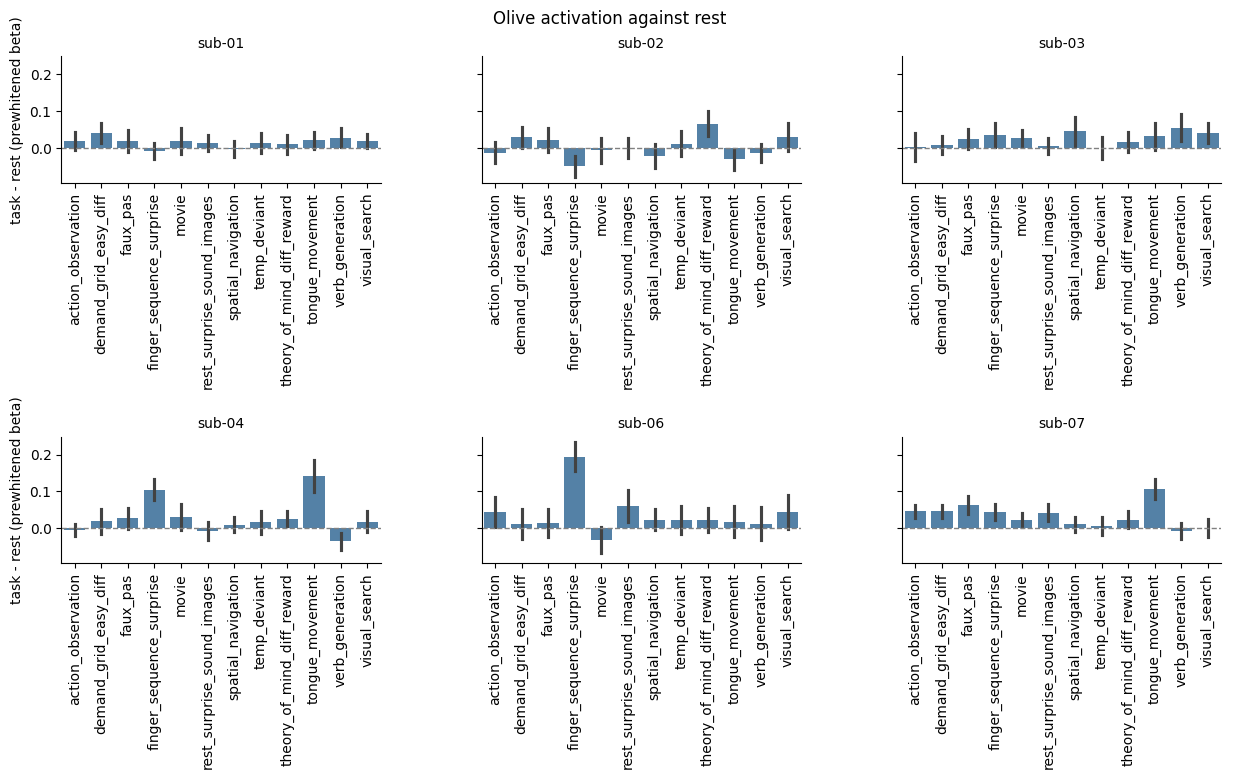

In [6]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import Functional_Fusion.dataset as ds

base_dir = '/Volumes/diedrichsen_data$/data/FunctionalFusion_new'
atlas_name = 'MNISymOlive1'
rest = 'rest'                                  # the task_code of your rest regressor

dataset = ds.DataSetNative(base_dir + '/Olive')

# 1. Table: one row per subject, task and run
rows = []
for s in dataset.get_participants().participant_id:
    d, inf = dataset.get_data(space=atlas_name, ses_id='ses-s1', type='CondRun', subj=[s])
    inf = inf.assign(roi=np.nanmean(d[0], axis=1))             # mean over olive voxels
    wide = inf.pivot(index='run', columns='task_code', values='roi')
    diff = wide.drop(columns=rest).sub(wide[rest], axis=0)     # task - rest per run
    long = diff.reset_index().melt(id_vars='run', var_name='task', value_name='activation')
    long['subj_id'] = s
    rows.append(long)
A = pd.concat(rows, ignore_index=True)

# 2. Plot: bar = mean across runs, line = standard error across runs
tasks = sorted(A.task.unique())
g = sns.catplot(data=A, x='task', y='activation', col='subj_id', col_wrap=3,
                order=tasks, kind='bar', errorbar='se', color='steelblue',
                height=3, aspect=1.4)
g.set_xticklabels(rotation=90)
g.set_axis_labels('', 'task - rest (prewhitened beta)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(range(len(tasks)))
    ax.set_xticklabels(tasks, rotation=90)
    ax.tick_params(axis='x', labelbottom=True)
g.figure.subplots_adjust(hspace=2)
g.figure.suptitle('Olive activation against rest', y=1.02)
plt.show()

In [7]:
import numpy as np, pandas as pd, nibabel as nb
from pathlib import Path
from scipy import stats
import Functional_Fusion.dataset as ds
import Functional_Fusion.atlas_map as am

base_dir = '/Volumes/diedrichsen_data$/data/FunctionalFusion_new'
atlas_name = 'MNISymCereb2'
task, rest = 'finger_sequence_surprise', 'rest'
right_runs = [1, 2, 3, 4, 13, 14, 15, 16]
left_runs = [5, 6, 7, 8, 9, 10, 11, 12]
out_dir = Path('/Users/incehusain/olive_contrasts')
out_dir.mkdir(exist_ok=True)

dataset = ds.DataSetNative(base_dir + '/Olive')
atlas, _ = am.get_atlas(atlas_name)
left_side = atlas.world[0] < 0                 # voxels left of the midline

summary = []
for s in dataset.get_participants().participant_id:
    d, inf = dataset.get_data(space=atlas_name, ses_id='ses-s1', type='CondRun', subj=[s])
    d = d[0]

    def task_minus_rest(runs):                 # runs x voxels
        return np.stack([d[((inf.run == r) & (inf.task_code == task)).values][0]
                         - d[((inf.run == r) & (inf.task_code == rest)).values][0]
                         for r in runs])

    R, L = task_minus_rest(right_runs), task_minus_rest(left_runs)
    con = R.mean(axis=0) - L.mean(axis=0)
    t = stats.ttest_ind(R, L, axis=0, equal_var=False).statistic

    names = ['right-rest', 'left-rest', 'right-left', 'right-left_tstat']
    img = atlas.data_to_cifti(np.vstack([R.mean(axis=0), L.mean(axis=0), con, t]), names)
    nb.save(img, out_dir / f'{s}_space-{atlas_name}_ses-s1_{task}_hand.dscalar.nii')

    summary.append({'subj_id': s,
                    'left_half': np.nanmean(con[left_side]),
                    'right_half': np.nanmean(con[~left_side])})

print(pd.DataFrame(summary).round(3))

  subj_id  left_half  right_half
0  sub-01      0.041       0.007
1  sub-02     -0.061       0.068
2  sub-03     -0.027       0.016
3  sub-04      0.072      -0.045
4  sub-06      0.086       0.025
5  sub-07      0.091       0.060
